# Setup

In [1]:
# install libraries if not installed

In [2]:
# import libraries
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.linear_model import LinearRegression, Lasso
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF 
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)
from ISLP.models import sklearn_sm
from ISLP.bart import BART
from functools import partial
from scipy import stats
from scipy.stats import shapiro


In [3]:
# check working directory
os.getcwd()

'c:\\Users\\carle\\Documents\\Cognitive_Science\\MASTER\\Data science\\Data science exam\\data_science'

# Data wrangling and dataset creation

In [4]:
# load data
gini = pd.read_csv('data/gini.csv', index_col=0, skiprows=3) # gini coefficient
gdp = pd.read_csv('data/gdp.csv', index_col=0, skiprows=3) # GDP
inflation = pd.read_csv('data/inflation.csv', index_col=0, skiprows=3) # inflation rate
unemployment = pd.read_csv('data/unemployment.csv', index_col=0, skiprows=3) # unemployment rate
income = pd.read_csv('data/Real wage.csv') # median real earnings
satisfaction = pd.read_csv('data/satisfaction.csv') # satsifaction with personal life and with the US
election_results = pd.read_csv('data/election_results.csv') # electoral outcomes

### Inspect data

In [5]:
# remove # to see the data
#gini


In [6]:
#gdp

In [7]:
#inflation

In [8]:
#unemployment

In [9]:
#income

In [10]:
#satisfaction

In [11]:
#election_results

### Filter, re-format and rename

#### Gini, GDP, inflation and unemployment

In [12]:
# filter rows - keep the US only
gini, gdp, inflation, unemployment = [
    df.loc[['United States']]
    for df in [gini, gdp, inflation, unemployment]
]

In [13]:
# filter columns - drop metadata
gini, gdp, inflation, unemployment = [
    df.drop(columns=["Country Code", "Indicator Name", "Indicator Code", "Unnamed: 70"])
    for df in [gini, gdp, inflation, unemployment]
]

In [14]:
# convert from wide to long format
gini, gdp, inflation, unemployment = [
    df.melt(var_name="year", value_name=name)
    for df, name in zip(
        [gini, gdp, inflation, unemployment],
        ["gini", "gdp", "inflation", "unemployment"]
    )
]

In [15]:
# convert "year" column from string to integer
gini['year'], gdp['year'], inflation['year'], unemployment['year'] = [
    df["year"].astype(int)
    for df in [gini, gdp, inflation, unemployment]
]

#### Income and satisfaction

In [16]:
# rename column
income = income.rename(columns={"LES1252881600Q": "median_real_wage"})

In [17]:
# extract year
income['year'] = income['observation_date'].str[:4]
income.head()

,observation_date,median_real_wage,year
0,1979-01-01,335.0,1979
1,1979-04-01,335.0,1979
2,1979-07-01,330.0,1979
3,1979-10-01,326.0,1979
4,1980-01-01,321.0,1980


In [18]:
# add column only with year
satisfaction['year'] = satisfaction['In general, are you satisfied or dissatisfied with the way things are going in [your personal life/the United States] at this time? <br><b>% Satisfied</b>'].str[-4:]

In [19]:
# take the mean of multiple observations during a single year
yearly_wage = income.groupby('year')['median_real_wage'].mean()
yearly_pers = satisfaction.groupby('year')['Personal life'].mean() # distribute satisfaction to satsfaction with personal life
yearly_us = satisfaction.groupby('year')['United States'].mean() # distribute satisfaction to satisfaction with the US

In [20]:
# convert each series into a dataframe
yearly_wage = pd.DataFrame(index= yearly_wage.index, data=yearly_wage.values, columns=['wage'])
yearly_pers = pd.DataFrame(index= yearly_pers.index, data=yearly_pers.values, columns=['pers'])
yearly_us = pd.DataFrame(index= yearly_us.index, data=yearly_us.values, columns=['us'])

In [21]:
# move year index back into a regular column
yearly_wage.reset_index(inplace=True)
yearly_pers.reset_index(inplace=True)
yearly_us.reset_index(inplace=True)


In [22]:
# make income and satisfaction integer
yearly_wage['year'] = yearly_wage['year'].astype(int)
yearly_pers['year'] = yearly_pers['year'].astype(int)
yearly_us['year'] = yearly_us['year'].astype(int)

In [23]:
# check that it worked (remove # to see the data)
#yearly_pers
#yearly_us
#yearly_wage

### Weighted average

In [24]:
# Create function and define weights for each year of the term (most recent year = highest weight)

def weighted_term_mean(df, value_column, election_years, weights):
    results = []
    for ey in election_years:
        term_years = list(range(ey - 3, ey + 1))  # 4 years leading up to election
        term_data = df[df['year'].isin(term_years)].sort_values('year')
        
        if len(term_data) >= 1:
            w = weights[-len(term_data):]
            w_mean = np.average(term_data[f'{value_column}'].values, weights=w)
        else:
            w_mean = np.nan  # not enough data
            
        results.append({'year': ey, f'{value_column}': w_mean})
    
    return pd.DataFrame(results)

weights = [0.1, 0.2, 0.3, 0.4] # define weights



In [25]:
# Apply weight function
gini_weighted = weighted_term_mean(gini, 'gini', election_results['year'].tolist(), weights) # gini
gdp_weighted = weighted_term_mean(gdp, 'gdp', election_results['year'].tolist(), weights) # GDP
unemployment_weighted = weighted_term_mean(unemployment, 'unemployment', election_results['year'].tolist(), weights) # unemployment
inflation_weighted = weighted_term_mean(inflation, 'inflation', election_results['year'].tolist(), weights) # inflation
wage_weighted = weighted_term_mean(yearly_wage, 'wage', election_results['year'].tolist(), weights) # income
pers_weighted = weighted_term_mean(yearly_pers, 'pers', election_results['year'].tolist(), weights) # satisfaction with personal life
us_weighted = weighted_term_mean(yearly_us, 'us', election_results['year'].tolist(), weights) # satisfaction with the US


In [26]:
# check - remove # to see the data
#inflation_weighted

In [27]:
#pers_weighted

### Merge data

In [28]:
# merge to single dataframe
prediction_data = pd.merge(election_results, gini_weighted, how='left', on='year') # gini
prediction_data = pd.merge(prediction_data, gdp_weighted, how = 'left', on=['year']) # GDP
prediction_data = pd.merge(prediction_data, unemployment_weighted, how = 'left', on=['year']) # unemployment
prediction_data = pd.merge(prediction_data, inflation_weighted, how = 'left', on=['year']) # inflation
prediction_data = pd.merge(prediction_data, wage_weighted, how = 'left', on=['year']) # income
prediction_data = pd.merge(prediction_data, pers_weighted, how = 'left', on=['year']) # satisaction with personal life
prediction_data = pd.merge(prediction_data, us_weighted, how = 'left', on=['year']) # satisfaction with the US


In [29]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,4.485057,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.738624,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.011149,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.067241,337.600,78.000000,14.000000
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.375905,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.351747,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,2.551376,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.830762,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,4.044309,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,3.464639,326.175,84.500000,50.400000


### Standardization and reformatting

In [30]:
# drop missing values - years before 1980
prediction_data = prediction_data.dropna()

In [31]:
# check
#prediction_data

In [32]:
# check types
prediction_data.dtypes

year                                                        int64
prospective conscutive term for incumbent party             int64
prospective 1st/2nd term for incumbent party candidate      int64
incumbent party                                            object
popular vote for incumbent party                          float64
popular vote for non-incumbent party                      float64
winner party                                               object
winner president                                           object
loser                                                      object
gini                                                      float64
gdp                                                       float64
unemployment                                              float64
inflation                                                 float64
wage                                                      float64
pers                                                      float64
us        

In [33]:
# make ordinal
enc = OrdinalEncoder(categories=[['1', '2', '3', '4']])  # specify order
prediction_data['prospective conscutive term for incumbent party'] = enc.fit_transform(prediction_data[['prospective conscutive term for incumbent party']])

enc = OrdinalEncoder(categories=[['1', '2']])  # specify order
prediction_data['prospective 1st/2nd term for incumbent party candidate'] = enc.fit_transform(prediction_data[['prospective 1st/2nd term for incumbent party candidate']]) #maybe we should introduce a varibale reflecting the presence of populist candidates, or something regaridn the non-incumbent candidates

C:\Users\carle\AppData\Local\Temp\ipykernel_44548\4048338162.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['prospective conscutive term for incumbent party'] = enc.fit_transform(prediction_data[['prospective conscutive term for incumbent party']])
C:\Users\carle\AppData\Local\Temp\ipykernel_44548\4048338162.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['prospective 1st/2nd term for incumbent party candidate'] = enc.fit_transform(prediction_data[['prospective 1st/2

In [34]:
# check types
prediction_data.dtypes

year                                                        int64
prospective conscutive term for incumbent party           float64
prospective 1st/2nd term for incumbent party candidate    float64
incumbent party                                            object
popular vote for incumbent party                          float64
popular vote for non-incumbent party                      float64
winner party                                               object
winner president                                           object
loser                                                      object
gini                                                      float64
gdp                                                       float64
unemployment                                              float64
inflation                                                 float64
wage                                                      float64
pers                                                      float64
us        

In [35]:
# check
#prediction_data

In [36]:
# we see that the prediction is in reverse order (most recent year first), we flip that
# make years index
prediction_data = prediction_data.set_index('year')
# make years in ascending order
prediction_data = prediction_data.sort_index()

In [37]:
# check - remove # to see the data
#prediction_data

Now the data is in the right format, with one value for each variable for each election, no nas, and in the right order, everything has the right data type

# Exploratory analysis

In [38]:
# standardize for the exploratory analysis and to check for multicollinearity, the unstandardized data will be used later to avoid data leakage
scaled_prediction_data = prediction_data.copy()

cols_to_scale = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us']  # standardizing predictors that are not categroical and the outcome

sc = StandardScaler()
scaled_prediction_data[cols_to_scale] = sc.fit_transform(scaled_prediction_data[cols_to_scale])

scaled_prediction_data

,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
year,,,,,,,,,,,,,,,
1980,1.0,1.0,Democratic,41.00,50.70,Republican,Ronald Reagan,Jimmy Carter,-2.291322,-0.393346,0.330846,2.968804,-0.587584,-1.756298,-1.081536
1984,1.0,1.0,Republican,58.80,40.60,Republican,Ronald Reagan,Walter Mondale,-1.238640,1.491179,1.807505,0.523495,-1.186116,-1.303363,0.378828
1988,2.0,0.0,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,-0.986384,1.145824,0.095436,-0.076432,-0.431381,0.604745,1.286214
1992,3.0,1.0,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,-0.637107,-0.944981,0.459251,0.158689,-1.098526,-0.395085,0.096567
1996,1.0,1.0,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,0.279745,0.414211,-0.183346,-0.333541,-1.132102,0.542793,0.351179
2000,2.0,0.0,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,0.260341,1.492255,-1.270867,-0.446863,-0.308755,1.203610,1.773121
2004,1.0,1.0,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,0.498043,0.126423,-0.291206,-0.527835,0.221165,0.691477,1.195726
2008,2.0,0.0,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,0.818214,-1.182503,-0.651312,-0.112423,0.051824,0.026530,-0.885480
2012,1.0,1.0,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,0.687235,-0.928747,1.938978,-0.643234,0.235763,-1.274452,-1.458566


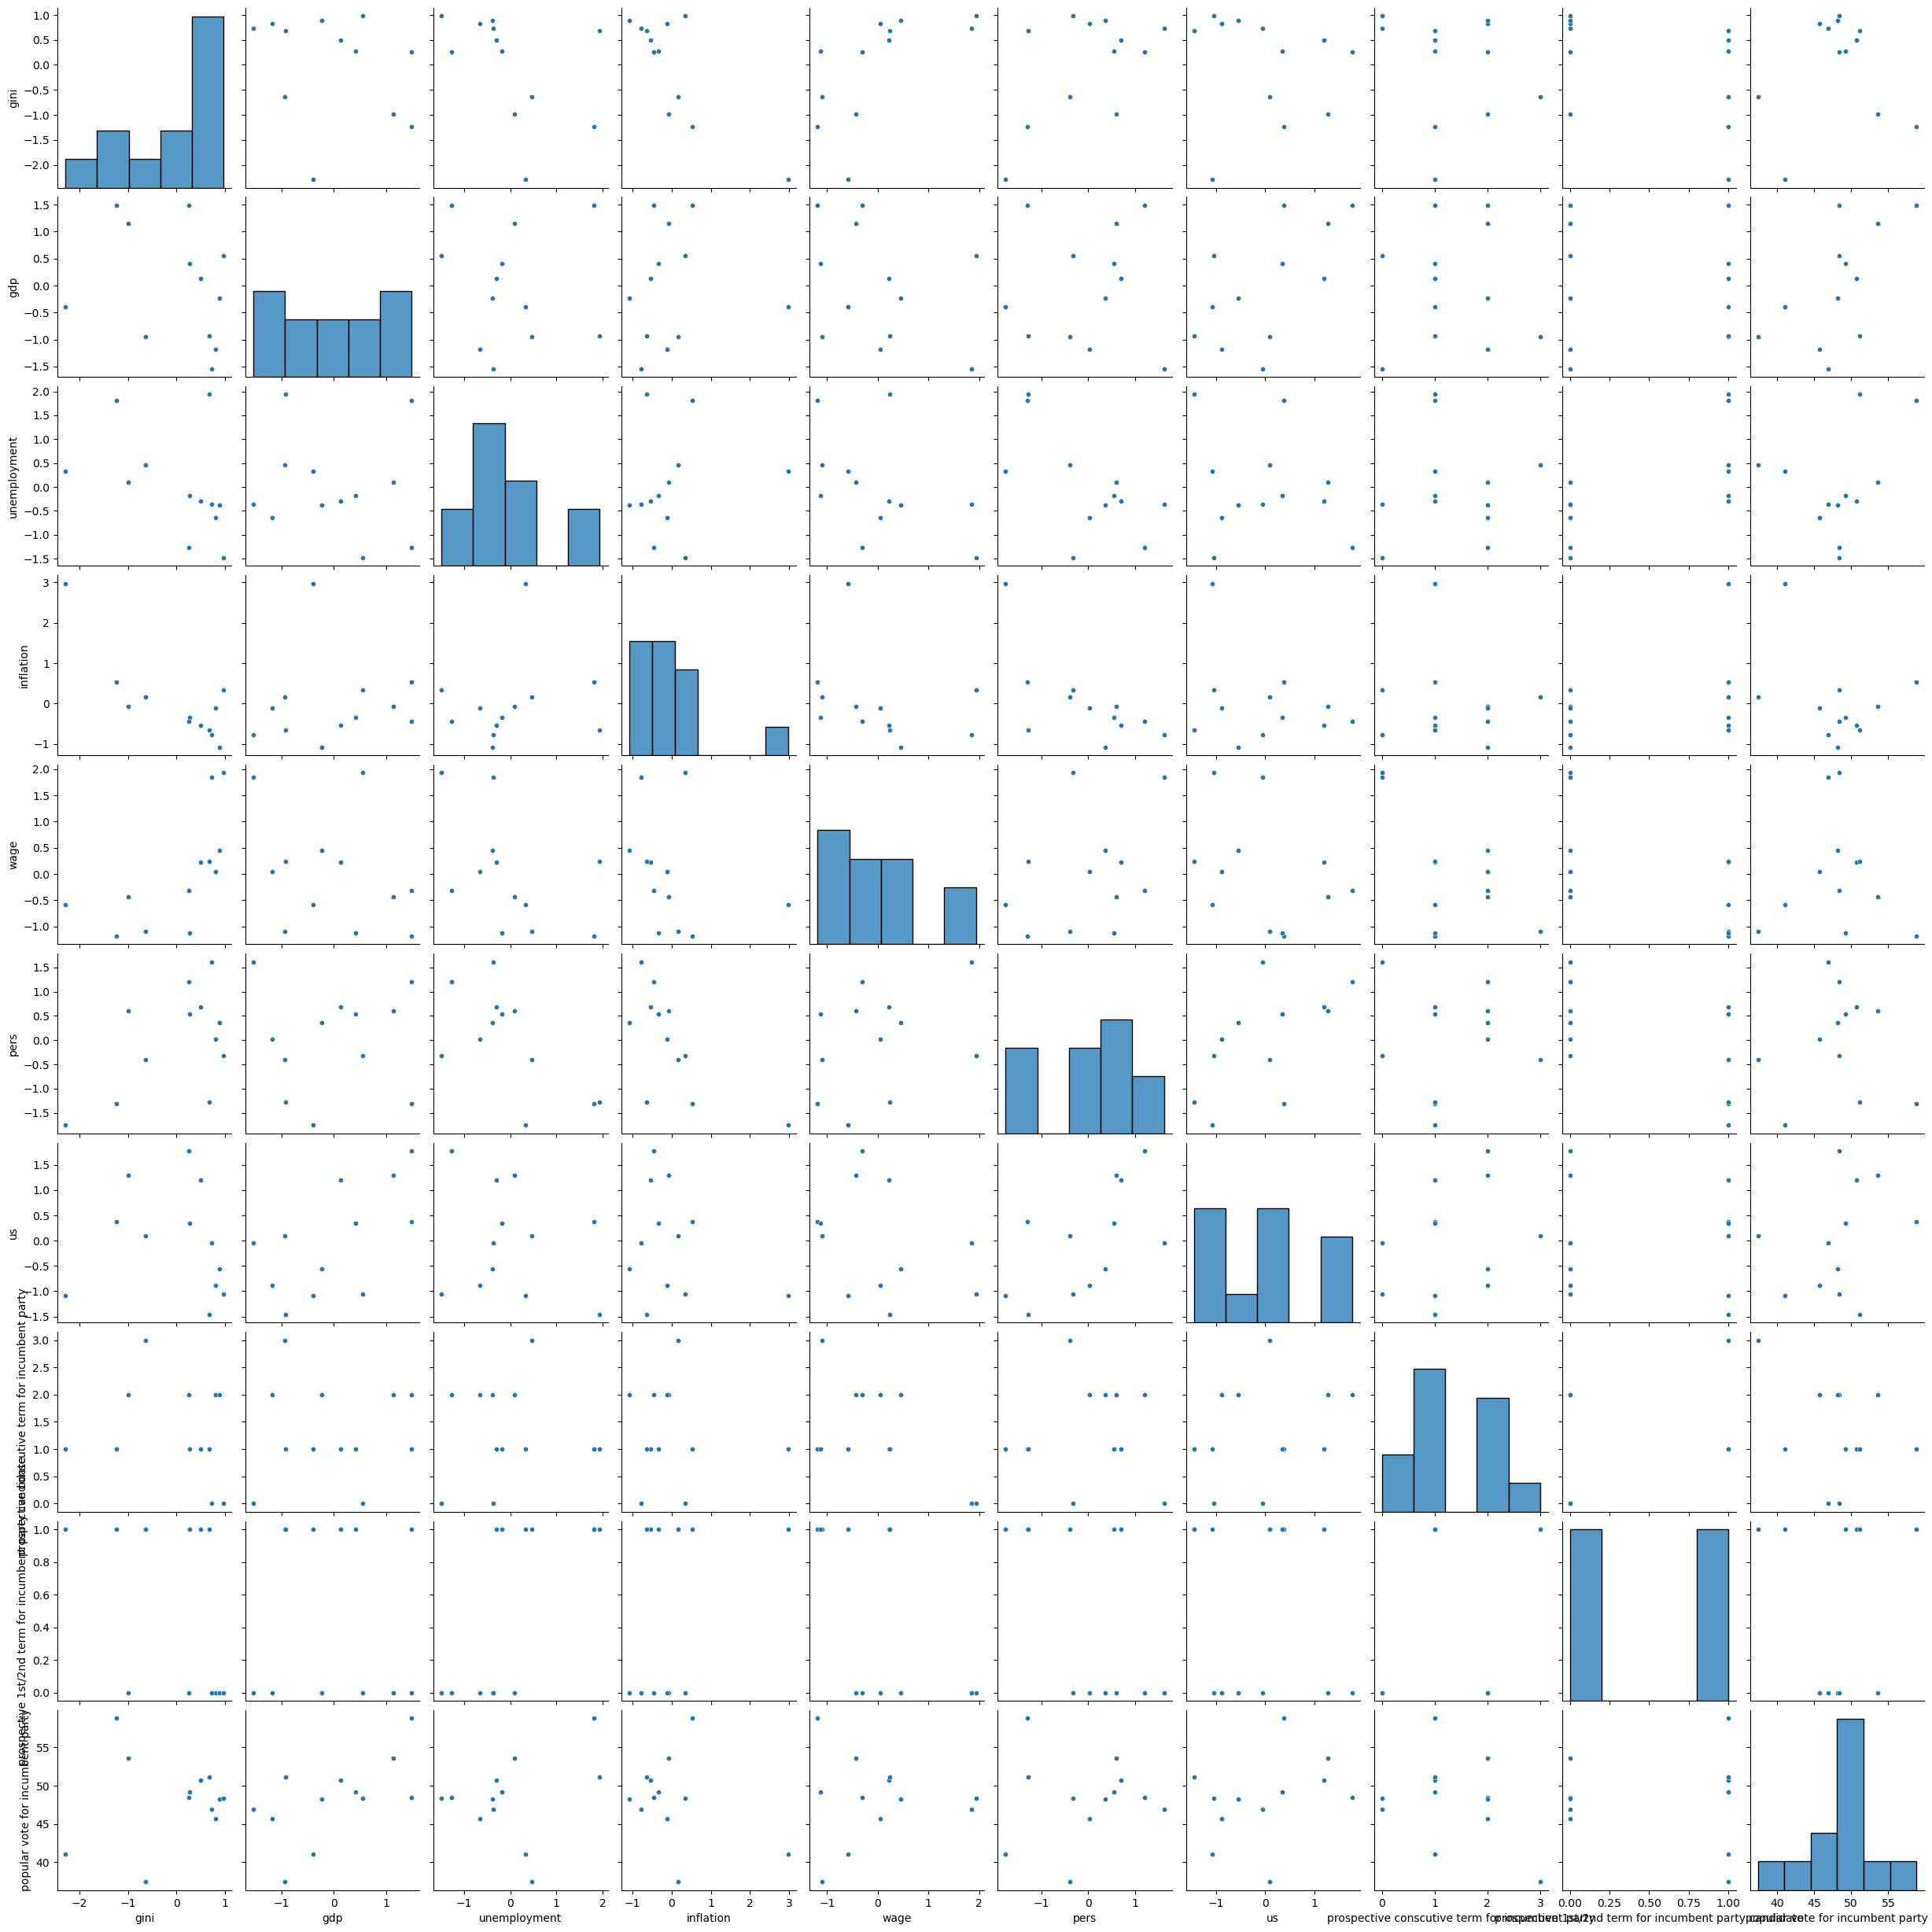

In [39]:
# plot colinearity
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate', 'popular vote for incumbent party']

sns.pairplot(scaled_prediction_data[cols], plot_kws={'alpha': 1, 's': 20})
plt.show()

We see that there is not that much data - but some patterns of collinearity seem to take shape

In [40]:
#Define funciton to calculate VIF for each predictor in different sets of predictors (e.g., only economic predictors, only SWB predictors, etc.)
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [VIF(X.values, i) for i in range(X.shape[1])]
    return vif

In [41]:
# calculate colinearity with VIF
X = scaled_prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]

calculate_vif(X)

,variables,VIF
0,gini,42.379545
1,gdp,4.013833
2,unemployment,22.838278
3,inflation,53.000320
4,wage,3.168965
5,pers,22.538819
6,us,11.596372
7,prospective conscutive term for incumbent party,4.666984
8,prospective 1st/2nd term for incumbent party c...,5.643797


In [42]:
# calculate colinearity with VIF

X = scaled_prediction_data[['pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]


calculate_vif(X)

,variables,VIF
0,pers,2.141974
1,us,1.668037
2,prospective conscutive term for incumbent party,1.761134
3,prospective 1st/2nd term for incumbent party c...,2.187852


In [43]:
# calculate colinearity with VIF

X = scaled_prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]


calculate_vif(X)

,variables,VIF
0,gini,8.395828
1,gdp,1.485186
2,unemployment,2.943521
3,inflation,5.976577
4,wage,2.472385
5,prospective conscutive term for incumbent party,2.543081
6,prospective 1st/2nd term for incumbent party c...,3.105601


In [44]:
# check normality to use pearsons
for col in cols:
    stat, p = shapiro(scaled_prediction_data[col])
    print(f"{col}: p = {p:.3f} {'✅ normal' if p > 0.05 else '❌ not normal'}")

gini: p = 0.033 ❌ not normal
gdp: p = 0.522 ✅ normal
unemployment: p = 0.266 ✅ normal
inflation: p = 0.004 ❌ not normal
wage: p = 0.114 ✅ normal
pers: p = 0.751 ✅ normal
us: p = 0.606 ✅ normal
prospective conscutive term for incumbent party: p = 0.160 ✅ normal
prospective 1st/2nd term for incumbent party candidate: p = 0.000 ❌ not normal
popular vote for incumbent party: p = 0.750 ✅ normal


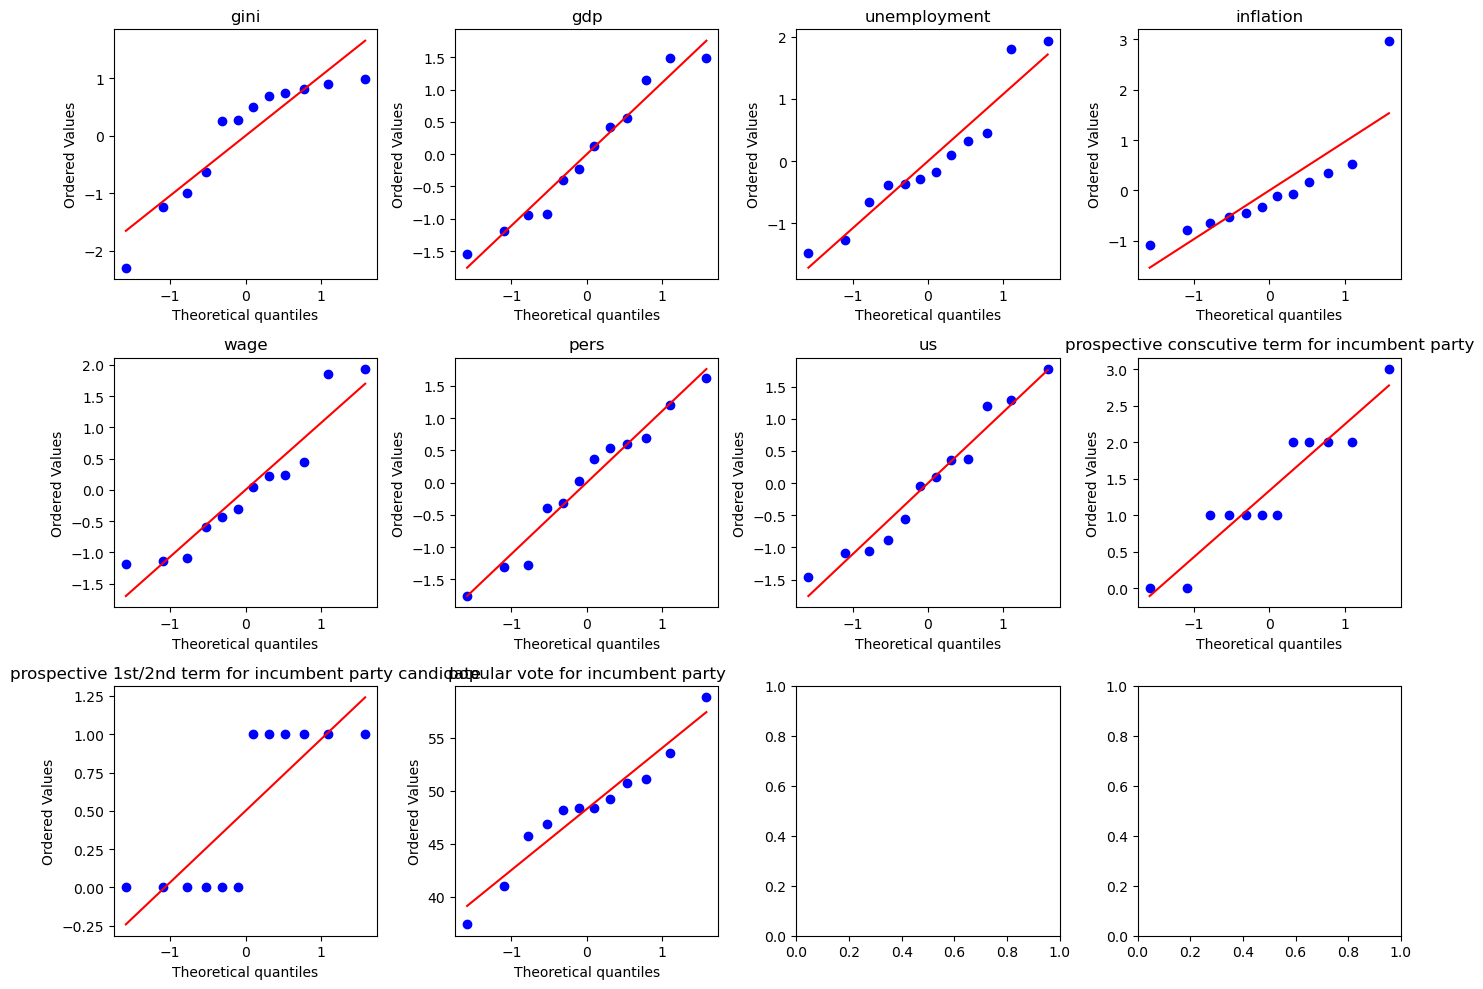

In [45]:
# check linearity to use pearsons

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    stats.probplot(scaled_prediction_data[col], plot=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

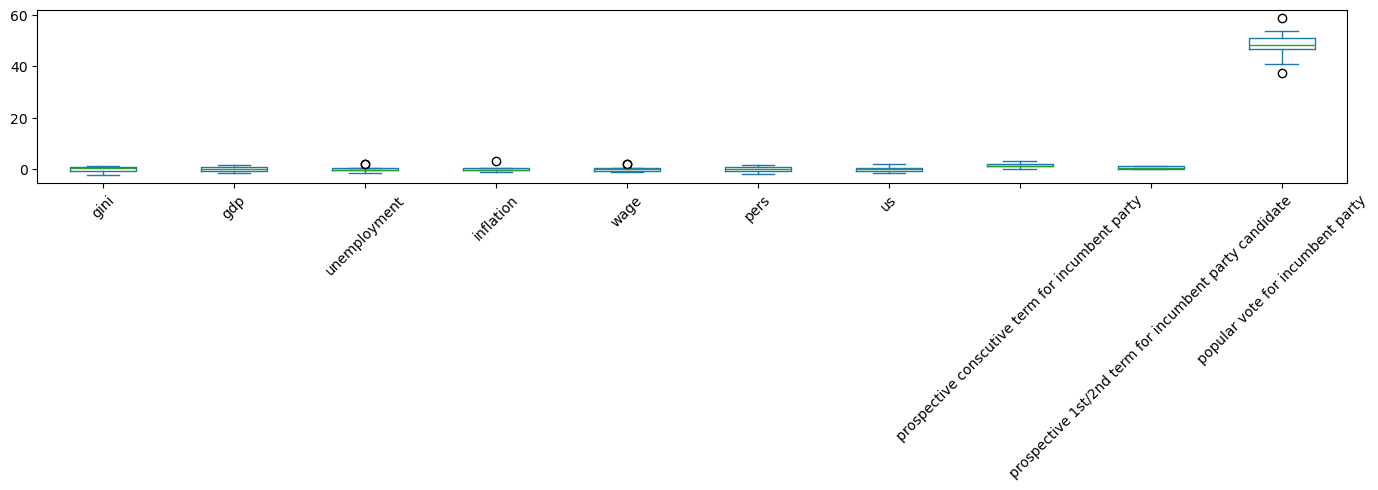

In [46]:
# check outliers
scaled_prediction_data[cols].plot(kind='box', figsize=(14, 5), rot=45)
plt.tight_layout()
plt.show()

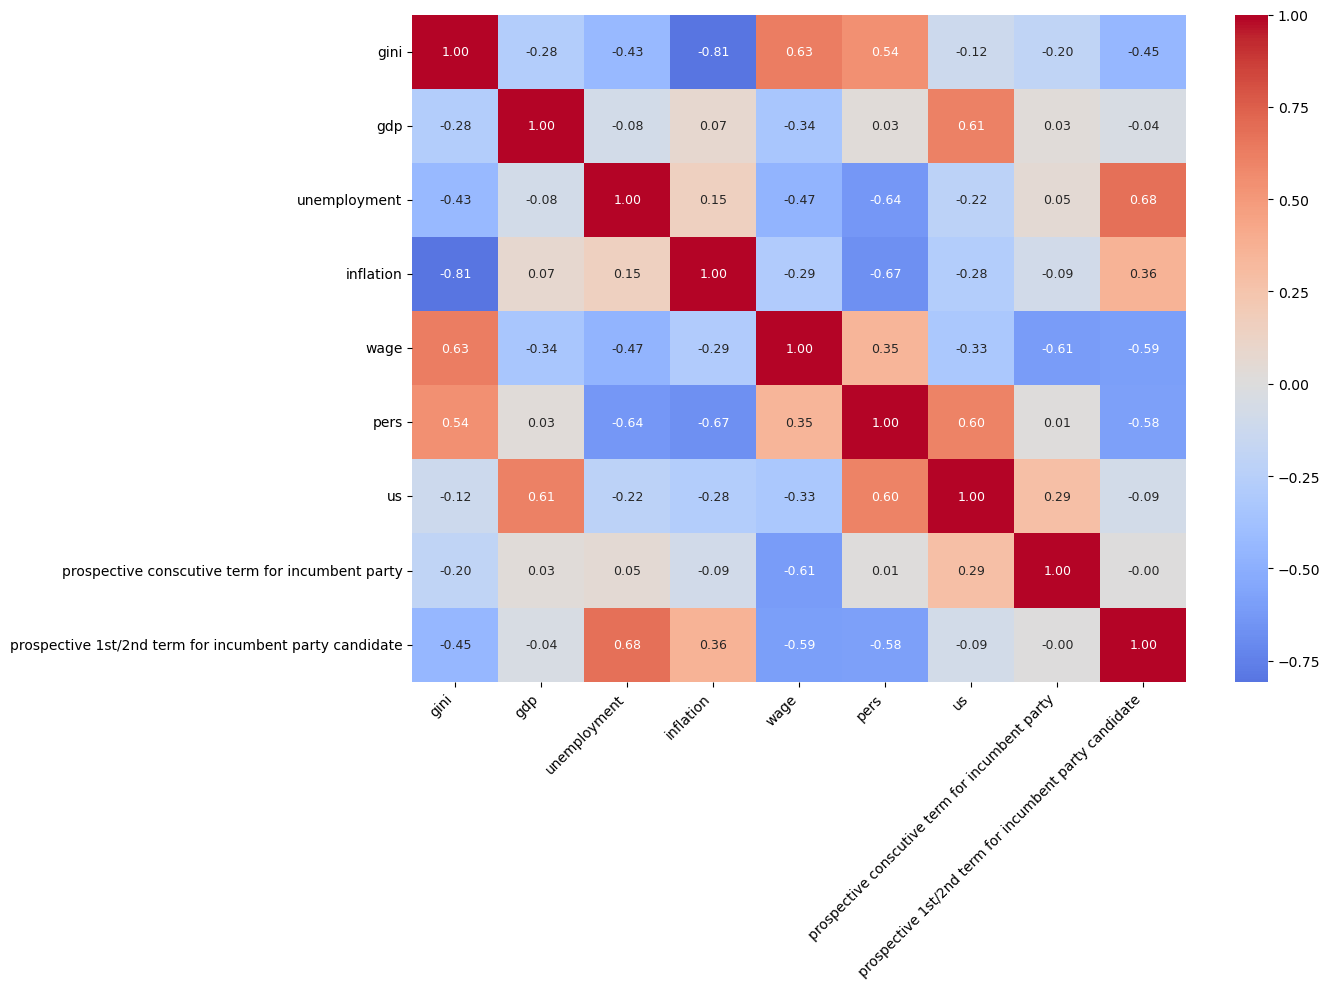

In [47]:
# correlation matrix (pearson)
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 
        'prospective conscutive term for incumbent party', 
        'prospective 1st/2nd term for incumbent party candidate']

corr = scaled_prediction_data[cols].corr()

# Heatmap
plt.figure(figsize=(14, 10))  # much bigger

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})  # smaller font so numbers fit

plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

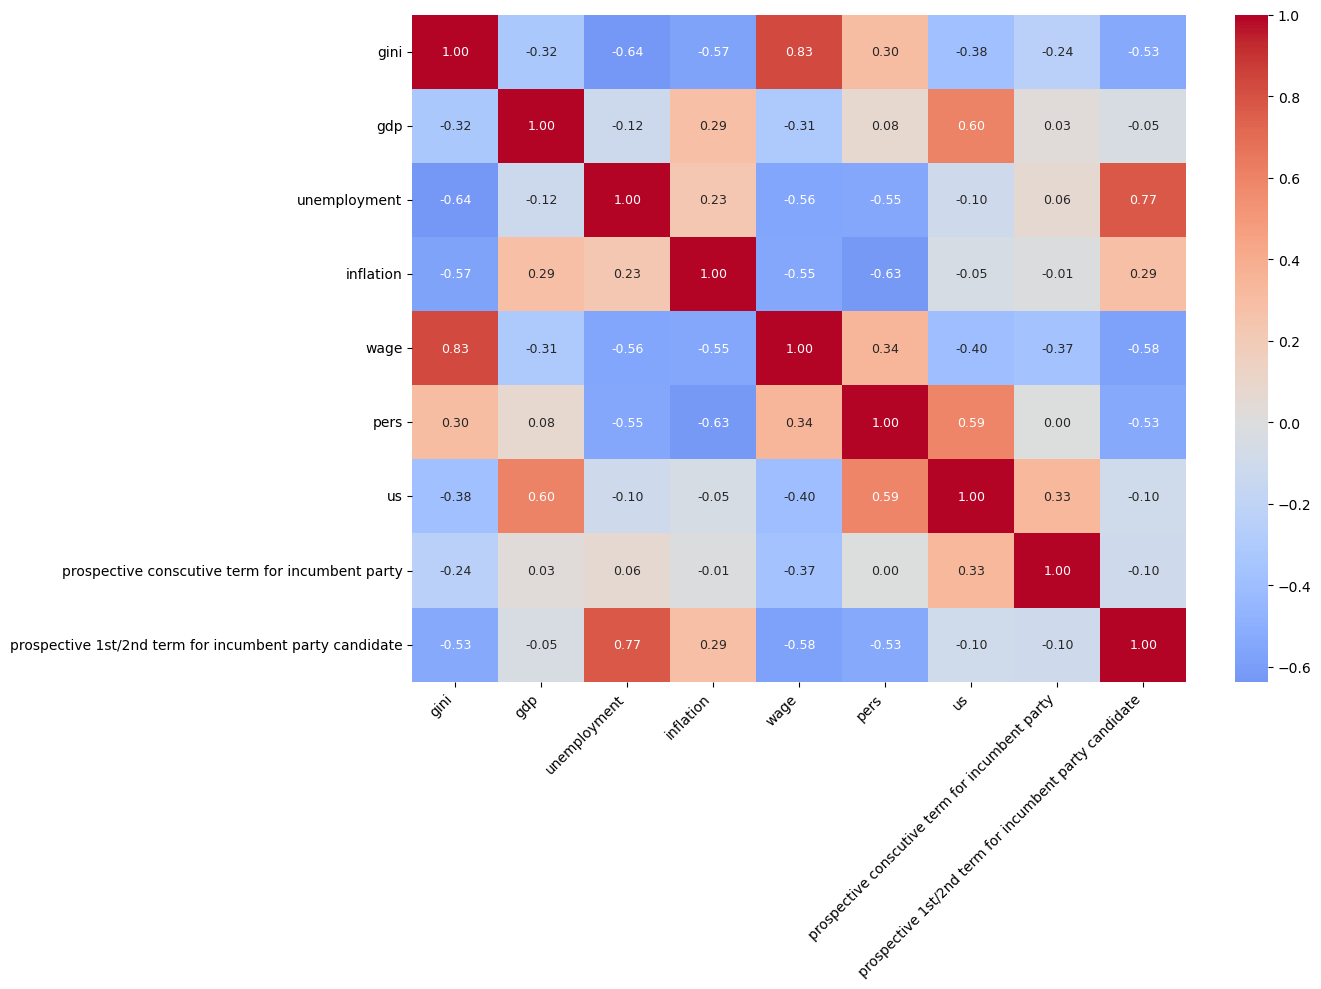

In [48]:
# spearman correlation matrix
corr_spearman = scaled_prediction_data[cols].corr(method='spearman')
corr_spearman

# Heatmap
plt.figure(figsize=(14, 10))  # much bigger

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})  # smaller font so numbers fit

plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

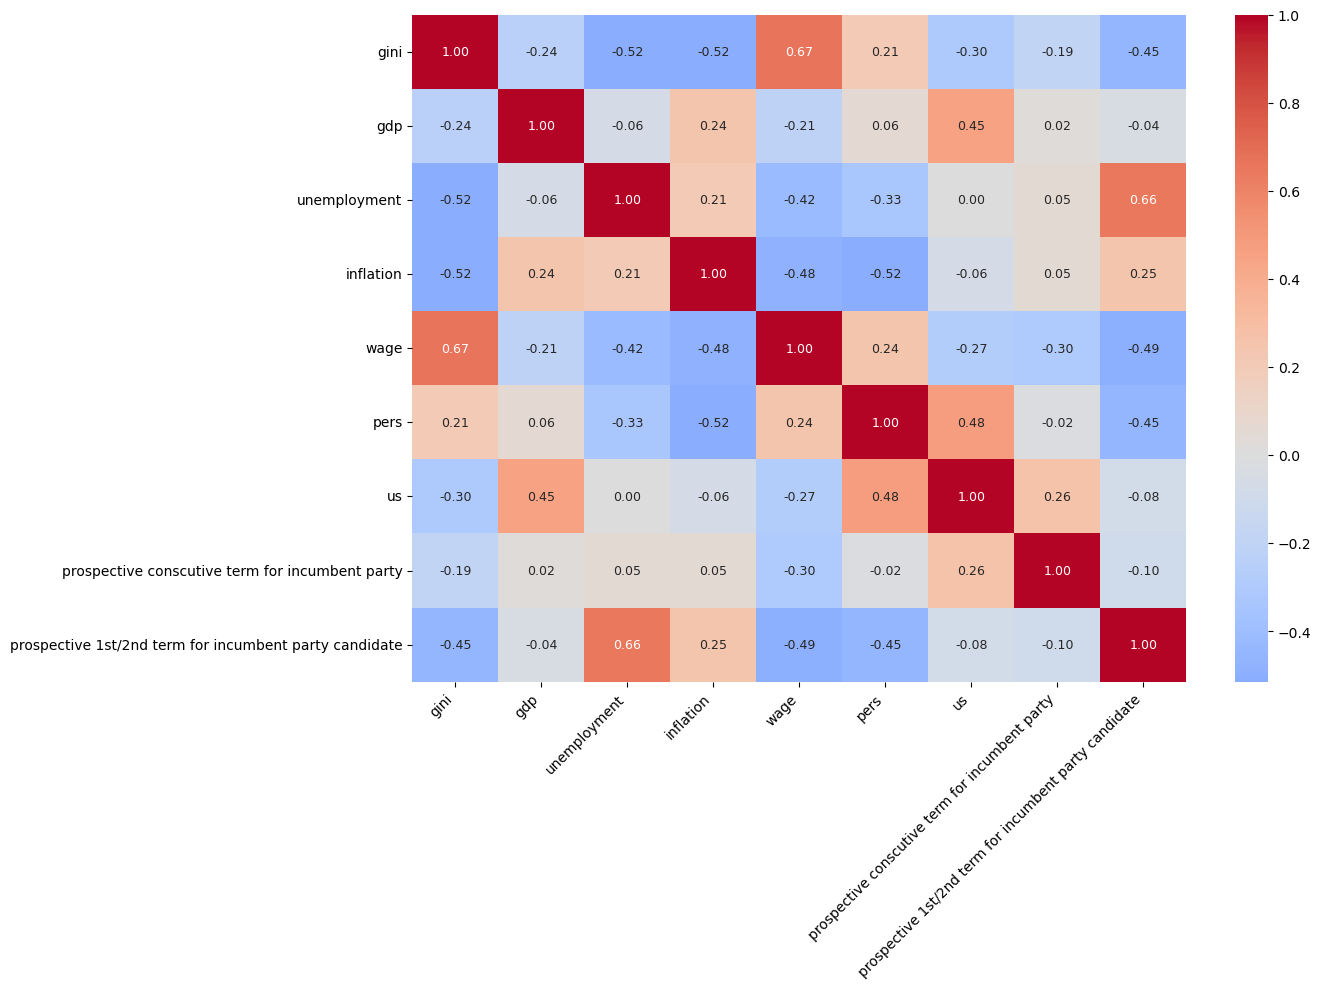

In [49]:
# kendall correlation matrix
corr_kendall = scaled_prediction_data[cols].corr(method='kendall')
corr_kendall

# Heatmap
plt.figure(figsize=(14, 10))  # much bigger

sns.heatmap(corr_kendall, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})  # smaller font so numbers fit

plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

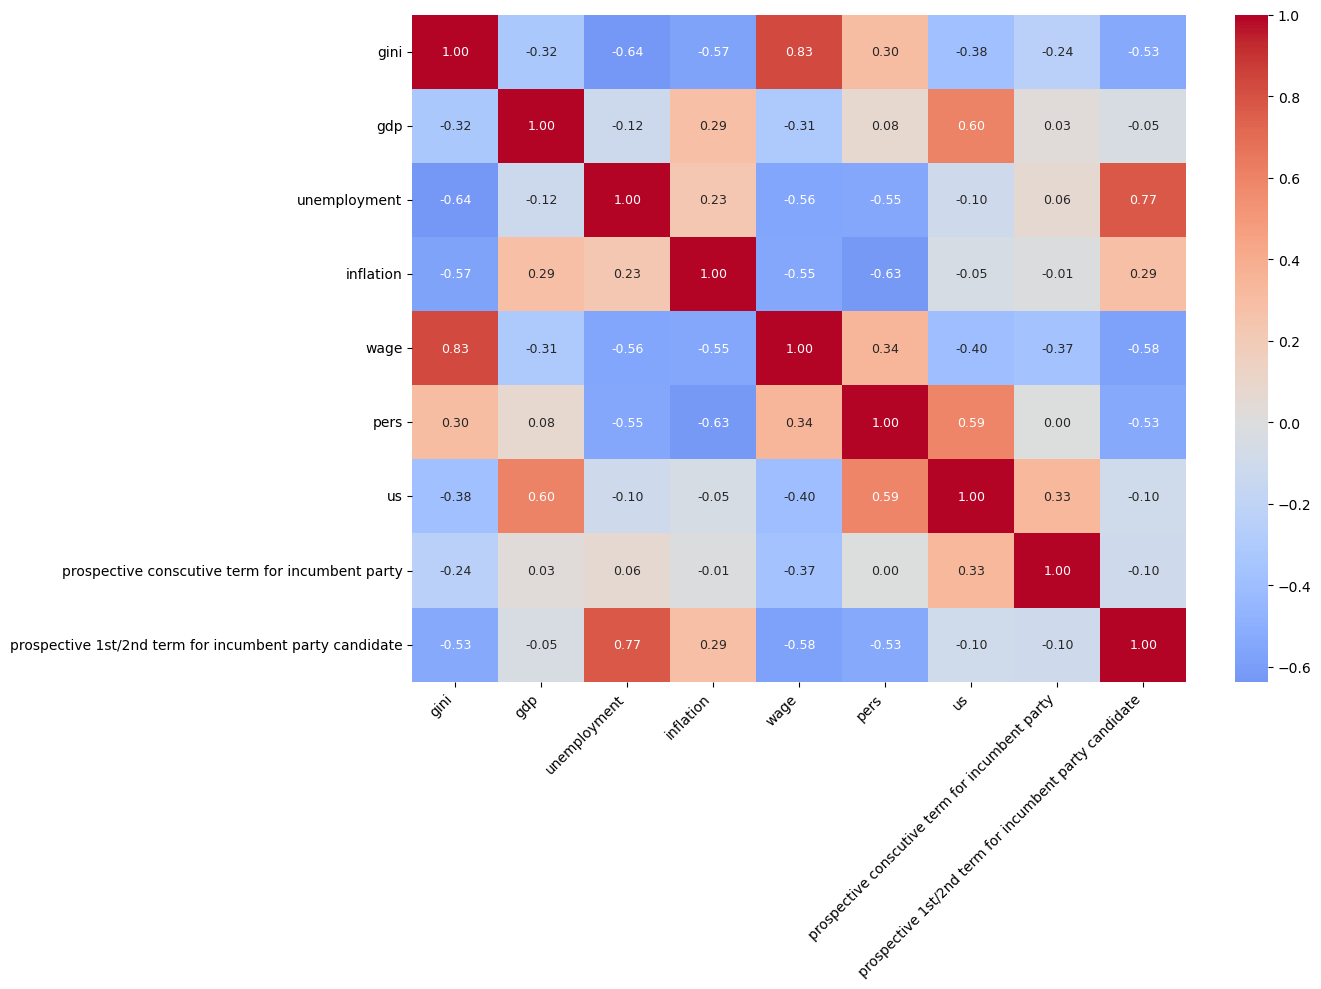

In [50]:
# save plot
plt.figure(figsize=(14, 10))

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_heatmap_spearman.jpg", dpi=150, bbox_inches='tight') 
plt.show()

High collinearity for some predictors

In [51]:
## pca
# performing PCA on economic predictors to reduce dimensionality and multicollinearity, and to create a composite economic index
econ_cols = ['gini', 'gdp','unemployment', 'inflation', 'wage']

# Scale first, PCA is sensitive to scale
scaler = StandardScaler()
econ_scaled = scaler.fit_transform(prediction_data[econ_cols])

# Fit PCA
pca = PCA()
pca.fit(econ_scaled)

# Check how many components to keep - how much variance is explained by each component
print(pd.Series(pca.explained_variance_ratio_, 
                index=[f'PC{i+1}' for i in range(len(econ_cols))]))


# Keep 3 components that explain most of the variance
pca = PCA(n_components=3)
econ_pca = pca.fit_transform(econ_scaled)

prediction_data['econ_PC1'] = econ_pca[:, 0]
prediction_data['econ_PC2'] = econ_pca[:, 1]
prediction_data['econ_PC3'] = econ_pca[:, 2]

# Check loadings to attemtp to interpret
loadings = pd.DataFrame(pca.components_.T, 
                         index=econ_cols, 
                         columns=['PC1', 'PC2', 'PC3'])
print(loadings)

PC1    0.502363
PC2    0.215500
PC3    0.190832
PC4    0.074008
PC5    0.017297
dtype: float64
                   PC1       PC2       PC3
gini          0.597454  0.005517 -0.232075
gdp          -0.223707  0.832381 -0.251917
unemployment -0.359798 -0.546687 -0.506378
inflation    -0.462596 -0.051187  0.670270
wage          0.499554 -0.074992  0.420713


# modelling:

## linear regression: 


In [52]:
#setting up the dataframes to store results of the models
all_cols = ['econ_PC1', 'econ_PC2', 'econ_PC3', 'gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']
cv_df = pd.DataFrame() # for cross-validation MSE
pred_df = pd.DataFrame() # for predictions for the last 3 elections
var_df = pd.DataFrame({'predictor': all_cols}) #for variable importance (only used for BART models)

In [53]:
# Null model
X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = []

pipe = Pipeline([
    ('features', MS(cols)),
    ('scaler', StandardScaler()),
    ('model', sklearn_sm(sm.OLS, MS(cols)))
])

tss = TimeSeriesSplit(n_splits=8, test_size=1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-3.5412102867731132


{'fit_time': array([0.01318526, 0.01044369, 0.01667094, 0.01930881, 0.01558447,
        0.00487089, 0.01206207, 0.01607633]),
 'score_time': array([0.00881314, 0.00551939, 0.        , 0.00299978, 0.00400066,
        0.        , 0.00176144, 0.00151086]),
 'test_score': array([-2.25000000e+00, -1.60000000e-01, -6.93444444e+00, -7.52326531e+00,
        -9.00000000e+00, -5.44444444e-02, -2.40250000e+00, -5.02809917e-03])}

In [54]:
# null model prdeicting last elections
cols = []
name = 'linear_null'

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# split to train on first 9 adn predict last 3 elections
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# Fit on training data, predict on last 3 elections
model = sklearn_sm(sm.OLS, MS(cols))
model.fit(X_train, Y_train)
predictions = model.predict(X_test)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'actual': Y_test.values,
    f'{name}': predictions.values
}, index=Y_test.index)



print(results_df)
print(mse)

      actual  linear_null
year                     
2016   48.20    48.433333
2020   46.86    48.433333
2024   48.34    48.433333
0.8461777777777736


In [55]:
# calcualting uncertainty of the null model 
data = prediction_data['popular vote for incumbent party'].dropna()

n = len(data)
mean = data.mean()
se = data.std() / np.sqrt(n)          # standard error of the mean

# Using t-distribution (correct for unknown population std)
ci = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)

print(f"Mean:  {mean:.4f}")
print(f"95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")

se_prediction = data.std() * np.sqrt(1 + 1/n)   # prediction SE, not standard error of mean

ci_prediction = stats.t.interval(0.95, df=n-1, loc=mean, scale=se_prediction)

print(f"Null model prediction: {mean:.4f}")
print(f"95% prediction interval: ({ci_prediction[0]:.4f}, {ci_prediction[1]:.4f})")

Mean:  48.2750
95% CI: (44.7755, 51.7745)
Null model prediction: 48.2750
95% prediction interval: (35.6574, 60.8926)


In [56]:
#adding null models metrics to the results dataframes
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])
pred_df = results_df
# checking the results
print(cv_df)
print(pred_df)


        method      MSE
0  linear_null  3.54121
      actual  linear_null
year                     
2016   48.20    48.433333
2020   46.86    48.433333
2024   48.34    48.433333


In [57]:
# all predictors model
name = 'linear_all'
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

#define the pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features,
    ('model', LinearRegression(fit_intercept = True))   # include intercept
])

tss = TimeSeriesSplit(n_splits=8, test_size= 1)

# crossvalidate the model using time series cross-validation
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-61.12592752052228


{'fit_time': array([0.00925183, 0.0063107 , 0.        , 0.0090909 , 0.00618029,
        0.0097692 , 0.00520992, 0.00608563]),
 'score_time': array([0.00199771, 0.        , 0.01320767, 0.00299788, 0.00541139,
        0.00201726, 0.0040195 , 0.00302887]),
 'test_score': array([  -3.12277737,  -17.49849814,  -26.01089633,  -55.23987903,
         -88.08550429,  -62.76353551, -177.39870428,  -58.88762521])}

In [58]:
# all predictors model prdeicting last elections
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# train on first 9 elections, predict last 3 elections
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)         # transform test with train's params

# Fit on training data, predict on last 3
model = LinearRegression(fit_intercept = True)
model.fit(X_train_scaled, Y_train)
predictions = model.predict(X_test_scaled)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'actual': Y_test.values,
    f'{name}': predictions
}, index=Y_test.index)

print(results_df)
print(mse)

      actual  linear_all
year                    
2016   48.20   40.277656
2020   46.86   62.663297
2024   48.34   39.603423
129.61183341351207


In [59]:
# add results to the results dataframes
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])
pred_df = pd.merge(pred_df, results_df, how='left', on=['year', 'actual'])

In [60]:
#probably delete
# econ predictors model
X = prediction_data[['econ_PC1', 'econ_PC2', 'econ_PC3', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

name = 'linear_econ_PCA'

cols = ['econ_PC1', 'econ_PC2', 'econ_PC3', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', LinearRegression(fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits=8, test_size=1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-31.40211108354188


{'fit_time': array([0.00896049, 0.01011825, 0.01128364, 0.00334287, 0.01049376,
        0.01043081, 0.        , 0.00299788]),
 'score_time': array([0.00409675, 0.00640559, 0.00612426, 0.01282001, 0.00560713,
        0.0059371 , 0.01218891, 0.        ]),
 'test_score': array([-35.20005143, -18.88733057, -59.78188804, -67.31374103,
        -21.64375565,  -0.42426359, -47.49802373,  -0.46783463])}

In [61]:
# probably delete
# econ predictors model prdeicting last elections
cols = ['econ_PC1', 'econ_PC2', 'econ_PC3', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)         # transform test with train's params

# Fit on training data, predict on last 3
model = Lasso(alpha = 1, fit_intercept = True)
model.fit(X_train_scaled, Y_train)
predictions = model.predict(X_test_scaled)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'actual': Y_test.values,
    f'{name}': predictions
}, index=Y_test.index)

print(results_df)
print(mse)

      actual  linear_econ_PCA
year                         
2016   48.20        48.366068
2020   46.86        50.850437
2024   48.34        50.690454
7.158599802332103


In [62]:
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])
pred_df = pd.merge(pred_df, results_df, how='left', on=['year', 'actual'])


In [ ]:
#define function to fit OLS model and print summary, will be used to check different sets of predictors
def fit_ols_model(cols):
    """Fit OLS model with constant term and print summary."""
    X = prediction_data[cols]
    X_const = sm.add_constant(X)
    model = sm.OLS(prediction_data['popular vote for incumbent party'], X_const).fit()
    print(model.summary())
    return model

In [ ]:
# Test with single predictors
for col in ['prospective 1st/2nd term for incumbent party candidate', 'prospective conscutive term for incumbent party', 
            'pers', 'gdp', 'inflation', 'us', 'unemployment', 'wage', 'gini']:
    print(f"\n{'='*60}\n{col}\n{'='*60}")
    fit_ols_model([col])


prospective 1st/2nd term for incumbent party candidate
                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.002
Model:                                          OLS   Adj. R-squared:                 -0.098
Method:                               Least Squares   F-statistic:                   0.02105
Date:                              Wed, 03 Jun 2026   Prob (F-statistic):              0.888
Time:                                      15:17:36   Log-Likelihood:                -36.967
No. Observations:                                12   AIC:                             77.93
Df Residuals:                                    10   BIC:                             78.90
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
              

c:\Users\carle\miniconda3\envs\datasci\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\carle\miniconda3\envs\datasci\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\carle\miniconda3\envs\datasci\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\carle\miniconda3\envs\datasci\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotes

In [66]:
#economic PCA model
cols = ['econ_PC1', 'econ_PC2', 'econ_PC3', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

fit_ols_model(cols)

                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.883
Model:                                          OLS   Adj. R-squared:                  0.786
Method:                               Least Squares   F-statistic:                     9.063
Date:                              Wed, 03 Jun 2026   Prob (F-statistic):            0.00914
Time:                                      19:22:45   Log-Likelihood:                -24.102
No. Observations:                                12   AIC:                             60.20
Df Residuals:                                     6   BIC:                             63.11
Df Model:                                         5                                         
Covariance Type:                          nonrobust                                         
                                                             coef    s

c:\Users\carle\miniconda3\envs\datasci\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [67]:
# Checking the gdp model, the best single predictor in term of r^2, for its crossvalidaiton performance
X = prediction_data[['gdp']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gdp']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', LinearRegression(fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits=8, test_size=1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-36.84773304938852


{'fit_time': array([0.00271749, 0.00493312, 0.00830293, 0.00559092, 0.00441837,
        0.        , 0.00908661, 0.00714254]),
 'score_time': array([0.00928068, 0.00755239, 0.00342131, 0.00264931, 0.        ,
        0.01526189, 0.00408864, 0.00310397]),
 'test_score': array([ -0.5365011 , -89.66823881, -29.5053308 , -64.92374114,
        -81.13255532,  -1.52624757, -23.77164619,  -3.71760346])}

In [68]:
# well-being predictors model
X = prediction_data[['pers','prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['pers',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', LinearRegression(fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits=8, test_size=1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-886.690703232095


{'fit_time': array([0.0076263 , 0.00715542, 0.00770998, 0.00134897, 0.00510383,
        0.00502658, 0.00506449, 0.        ]),
 'score_time': array([0.00342274, 0.00240469, 0.00349545, 0.00810671, 0.00370026,
        0.00307488, 0.00246239, 0.00853276]),
 'test_score': array([-6.74904699e+03, -3.38554441e+01, -9.01432469e-02, -2.32121775e+01,
        -4.20335488e+00, -6.79144254e-01, -2.55959204e+02, -2.64791678e+01])}

In [69]:
X = prediction_data[['pers',
                      'prospective conscutive term for incumbent party', 
                      'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.110
Model:                                          OLS   Adj. R-squared:                 -0.224
Method:                               Least Squares   F-statistic:                    0.3296
Date:                              Wed, 03 Jun 2026   Prob (F-statistic):              0.804
Time:                                      19:24:04   Log-Likelihood:                -36.280
No. Observations:                                12   AIC:                             80.56
Df Residuals:                                     8   BIC:                             82.50
Df Model:                                         3                                         
Covariance Type:                          nonrobust                                         
                                                             coef    s

c:\Users\carle\miniconda3\envs\datasci\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)


## NOW LASSO

In [95]:
def Lasso_cv(cols, name, alpha=1, all_interactions=False):
    X = prediction_data[cols]
    Y = prediction_data['popular vote for incumbent party']

    if all_interactions:
        X = PolynomialFeatures(interaction_only=True).fit_transform(X)

    pipe = Pipeline([
        ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = alpha, fit_intercept = True))   # handles intercept separately via fit_intercept=True
    ])

    tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

    # Pass the full dataset — MS handles column selection inside the pipeline
    cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
    cv_err = np.mean(cv_results['test_score'])
    print(cv_err)
    cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})

    # check coefficients importance VEND EVT TILBAGE
    pipe.fit(X, Y)

    coefs = pd.Series(pipe.named_steps['model'].coef_)
    print(coefs)
    print('intercept:', pipe.named_steps['model'].intercept_)

    return cv_df_temp

In [96]:
# all predictors model_no interacitons
name = 'lasso_high_alpha'

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

cv_df_temp = Lasso_cv(cols, name, alpha=10)
cv_df = pd.concat([cv_df, cv_df_temp])

-3.5412102867731106
0    0.0
1    0.0
2    0.0
3   -0.0
4   -0.0
5    0.0
6    0.0
7   -0.0
8   -0.0
dtype: float64
intercept: 48.275000000000006


In [97]:
# all predictors model_no interacitons
name = 'lasso_all_no_int'

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

cv_df_temp = Lasso_cv(cols, name, alpha=1)
cv_df = pd.concat([cv_df, cv_df_temp])

-20.280565988388844
0    0.000000
1    2.392725
2    0.967417
3   -1.090206
4    0.000000
5    0.000000
6    0.000000
7   -0.953909
8   -0.000000
dtype: float64
intercept: 48.275000000000006


In [98]:
# all predictors model - all interactions
name = 'lasso_all_all_int'

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

cv_df_temp = Lasso_cv(cols, name, alpha=1, all_interactions=True)
cv_df = pd.concat([cv_df, cv_df_temp])

-29.6886876149496
0     0.000000
1     0.000000
2     0.000000
3     0.000000
4    -0.000000
5     0.000000
6     0.000000
7     0.000000
8    -0.000000
9    -0.000000
10    0.000000
11    0.245310
12   -0.000000
13    0.000000
14    0.000000
15    0.000000
16   -0.000000
17   -0.000000
18    2.890702
19   -0.000000
20    0.000000
21    0.000000
22    0.000000
23    0.000000
24    0.000000
25   -0.000000
26    0.000000
27    0.000000
28    0.000000
29   -0.000000
30    0.000000
31   -0.000000
32   -0.000000
33   -0.000000
34   -1.758618
35   -0.000000
36    0.000000
37    0.000000
38   -0.000000
39   -0.000000
40    0.000000
41   -0.000000
42   -0.000000
43   -0.000000
44   -0.000000
45   -0.353527
dtype: float64
intercept: 48.275000000000006


In [99]:
# econ predictors model_no interactions
name = 'lasso_raw_econ_no_int'

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

cv_df_temp = Lasso_cv(cols, name, alpha=1)
cv_df = pd.concat([cv_df, cv_df_temp])

-20.280565988388844
0    0.000000
1    2.392725
2    0.967417
3   -1.090206
4    0.000000
5   -0.953909
6   -0.000000
dtype: float64
intercept: 48.275000000000006


In [100]:
# econ predictors model _all nteractions
name = 'lasso_raw_econ_all_int'

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

cv_df_temp = Lasso_cv(cols, name, alpha=1, all_interactions=True)
cv_df = pd.concat([cv_df, cv_df_temp])

-29.417400824779595
0     0.000000
1     0.000000
2     0.000000
3     0.000000
4    -0.000000
5     0.000000
6    -0.000000
7    -0.000000
8     0.000000
9     0.245311
10   -0.000000
11    0.000000
12   -0.000000
13   -0.000000
14    2.890701
15   -0.000000
16    0.000000
17    0.000000
18    0.000000
19   -0.000000
20    0.000000
21   -0.000000
22    0.000000
23   -0.000000
24   -1.758616
25   -0.000000
26   -0.000000
27   -0.000000
28   -0.353529
dtype: float64
intercept: 48.275000000000006


In [101]:
# econ predictors model - gini no nteractions
name = 'lasso_no_gini_econ_no_int'

cols = ['gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

cv_df_temp = Lasso_cv(cols, name, alpha=1)
cv_df = pd.concat([cv_df, cv_df_temp])

-20.280523879648214
0    2.392725
1    0.967417
2   -1.090206
3    0.000000
4   -0.953909
5   -0.000000
dtype: float64
intercept: 48.275000000000006


In [110]:
name = 'lasso_no_gini_econ_all_int'

cols = ['gdp', 'unemployment', 'inflation', 'wage',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']


cv_df_temp = Lasso_cv(cols, name, alpha=1, all_interactions=True)
cv_df = pd.concat([cv_df, cv_df_temp])


-27.41761125948145
0     0.000000
1     0.000000
2     0.000000
3    -0.000000
4     0.000000
5    -0.000000
6    -0.000000
7     2.921689
8    -0.000000
9     0.000000
10    0.000000
11    0.000000
12   -0.000000
13    0.133582
14   -0.000000
15    0.000000
16   -0.000000
17   -1.805056
18   -0.000000
19   -0.000000
20   -0.000000
21   -0.273969
dtype: float64
intercept: 48.275000000000006


In [105]:
# econ predictors model - gini _all nteractions
name = 'lasso_econ_PC2'

cols = ['econ_PC1', 'econ_PC2',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

cv_df_temp = Lasso_cv(cols, name, alpha=1)
cv_df = pd.concat([cv_df, cv_df_temp])

-38.8748166103475
0   -0.000000
1    0.875618
2   -0.764325
3    0.000000
dtype: float64
intercept: 48.275000000000006


In [107]:
# econ predictors model - gini _all nteractions
name = 'lasso_econ_PC3'

cols = ['econ_PC1', 'econ_PC2', 'econ_PC3',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

cv_df_temp = Lasso_cv(cols, name, alpha=1)
cv_df = pd.concat([cv_df, cv_df_temp])

-18.563175561560687
0   -0.000000
1    0.909373
2   -2.423728
3   -1.531987
4   -0.000000
dtype: float64
intercept: 48.275000000000006


In [109]:
# econ predictors model - gini _all nteractions
name = 'lasso_econ_PC3_all_int'

cols = ['econ_PC1', 'econ_PC2', 'econ_PC3',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

cv_df_temp = Lasso_cv(cols, name, alpha=1, all_interactions=True)
cv_df = pd.concat([cv_df, cv_df_temp])

-46.648480710147766
0     0.000000
1    -0.086077
2     0.000000
3    -1.469525
4    -0.796118
5     0.000000
6    -0.000000
7     0.000000
8    -0.000000
9    -0.000000
10    0.000000
11    0.772591
12    0.000000
13   -0.000000
14   -0.959140
15   -0.910160
dtype: float64
intercept: 48.275000000000006


In [111]:
# econ predictors model - gini _all nteractions
name = 'lasso_pers_all_int'

cols = ['pers',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

cv_df_temp = Lasso_cv(cols, name, alpha=1, all_interactions=True)
cv_df = pd.concat([cv_df, cv_df_temp])

-13.260680375876065
0    0.000000
1   -0.000000
2   -0.276340
3    0.000000
4   -0.000000
5    0.000000
6   -1.168662
dtype: float64
intercept: 48.275000000000006


In [112]:
# econ predictors model - gini _all nteractions
name = 'lasso_well_all_int'

cols = ['pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

cv_df_temp = Lasso_cv(cols, name, alpha=1, all_interactions=True)
cv_df = pd.concat([cv_df, cv_df_temp])

-23.25285454334789
0     0.000000
1    -0.000000
2     0.727203
3    -0.530802
4     0.000000
5     0.000000
6    -0.000000
7     0.000000
8    -0.000000
9     0.000000
10   -1.047641
dtype: float64
intercept: 48.275000000000006


In [ ]:
# all predictors model prdeicting last elections
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

poly = PolynomialFeatures(interaction_only=True, include_bias=False)
X_poly = pd.DataFrame(poly.fit_transform(X), 
                       columns=poly.get_feature_names_out(cols),
                       index=X.index)  # ← preserve index for iloc to work

# Split: everything except last 3 = train, last 3 = test
X_train, X_test = X_poly[:-3], X_poly[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)         # transform test with train's params

# Fit on training data, predict on last 3
model = Lasso(alpha = 1, fit_intercept = True)
model.fit(X_train_scaled, Y_train)
predictions = model.predict(X_test_scaled)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions
}, index=Y_test.index)

print(results_df)
print(mse)


      Actual  Predicted
year                   
2016   48.20  50.164787
2020   46.86  48.607933
2024   48.34  51.725987
6.126855947453961


In [115]:
# all predictors model prdeicting last elections
cols = ['pers', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

poly = PolynomialFeatures(interaction_only=True, include_bias=False)
X_poly = pd.DataFrame(poly.fit_transform(X), 
                       columns=poly.get_feature_names_out(cols),
                       index=X.index)  # ← preserve index for iloc to work

# Split: everything except last 3 = train, last 3 = test
X_train, X_test = X_poly[:-3], X_poly[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)         # transform test with train's params

# Fit on training data, predict on last 3
model = Lasso(alpha = 1, fit_intercept = True)
model.fit(X_train_scaled, Y_train)
predictions = model.predict(X_test_scaled)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions
}, index=Y_test.index)

print(results_df)
print(mse)


      Actual  Predicted
year                   
2016   48.20  48.948400
2020   46.86  53.988757
2024   48.34  53.988757
27.76258070418916


In [116]:
feature_names = poly.get_feature_names_out(cols)
non_zero = pd.Series(model.coef_, index=feature_names)
print(non_zero[non_zero != 0])

prospective conscutive term for incumbent party                                                          -1.726158
prospective conscutive term for incumbent party prospective 1st/2nd term for incumbent party candidate   -1.609394
dtype: float64


## BART

In [117]:
def bart_cv(cols, name, burnin = 5, ndraw = 15):
    X = prediction_data[cols]
    Y = prediction_data['popular vote for incumbent party']

    model = BART(random_state =0, burnin = burnin, ndraw = ndraw)  

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    tss = TimeSeriesSplit(n_splits=8, test_size=1)

    # Pass the full dataset — MS handles column selection inside the pipeline
    cv_results = cross_validate(pipe, X, Y, cv=tss,  scoring='neg_mean_squared_error')
    cv_err = np.mean(cv_results['test_score'])
    cv_df = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})

    print(cv_err)
    print(cv_results)
    return(cv_df)


In [118]:
def bart_pred(cols, name, burnin = 5, ndraw = 15, n_elections = 3):
    X = prediction_data[cols]
    Y = prediction_data['popular vote for incumbent party']

    # split the last n elections for test
    X_train, X_test = X.iloc[:-n_elections], X.iloc[-n_elections:]
    Y_train, Y_test = Y.iloc[:-n_elections], Y.iloc[-n_elections:]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
    X_test_scaled = scaler.transform(X_test)         # transform test with train's params

    # Fit on training data, predict on last 2
    model = BART(random_state = 0, burnin= burnin, ndraw = ndraw, num_trees=200)
    model.fit(X_train_scaled, Y_train)
    predictions = model.predict(X_test_scaled.astype(np.float32))

    mse = np.mean((Y_test - predictions)**2)

    var_inclusion = pd.Series(model. variable_inclusion_ .mean (0),  index=X.columns) 
    print(var_inclusion)
    var_df = pd.DataFrame({'predictor': var_inclusion.index, f'{name}_inclusion': var_inclusion.values})

    # Compare predictions vs actuals
    results_df = pd.DataFrame({
        'actual': Y_test.values,
        f'{name}': predictions
    }, index=Y_test.index)
    print(results_df)
    print(mse)
    return(results_df, var_df)

In [119]:
# CV bart all predictors
# model including all predictors - BART - light
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_all'

cv_df_temp = bart_cv(cols, name)
cv_df = pd.concat([cv_df, cv_df_temp])
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
pred_df_temp, var_df_temp = bart_pred(cols, name)
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

KeyboardInterrupt: 

In [ ]:
#bart economic
# model includin predictors - BART - light
cols = ['econ_PC1', 'econ_PC2',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_econ'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp = bart_pred(cols, name)
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

KeyboardInterrupt: 

In [ ]:
#bart economic
# model including all predictors - BART - light
cols = ['econ_PC1', 'econ_PC2', 'econ_PC3',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_econ'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp = bart_pred(cols, name)
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

-4.253227524536049
{'fit_time': array([6.8649509 , 6.58759856, 6.87279773, 6.54177213, 6.58805943,
       7.0034039 , 6.9220891 , 6.81385016]), 'score_time': array([0.03680468, 0.03313136, 0.0338881 , 0.02939987, 0.03062439,
       0.034904  , 0.03530574, 0.02504134]), 'test_score': array([-7.39090385e+00, -1.61691220e+00, -1.24637536e+01, -1.18221645e-02,
       -6.27932192e+00, -9.79868660e-01, -5.48643669e-01, -4.73459413e+00])}
econ_PC1                                                  60.800000
econ_PC2                                                  59.800000
econ_PC3                                                  60.533333
prospective conscutive term for incumbent party           62.533333
prospective 1st/2nd term for incumbent party candidate    59.066667
dtype: float64
      actual  bart_econ
year                   
2016   48.20  47.518399
2020   46.86  45.496030
2024   48.34  48.391877
0.7758953686404734


In [ ]:
#bart economic
# model including all predictors - BART - light
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_econ'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp = bart_pred(cols, name)
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

-5.485598549058068
{'fit_time': array([6.91230512, 6.7508502 , 6.7450583 , 6.7995851 , 9.52259159,
       7.76382184, 7.2932837 , 7.65057135]), 'score_time': array([0.03816867, 0.0366323 , 0.0383625 , 0.03701377, 0.03953838,
       0.03442907, 0.04086661, 0.03401732]), 'test_score': array([ -3.24197994,  -1.1050932 ,  -7.08741804,  -1.48906259,
       -14.17366596,  -0.16271017,  -1.26811492, -15.35674358])}
gini                                                      43.933333
gdp                                                       45.133333
unemployment                                              39.800000
inflation                                                 41.466667
wage                                                      46.666667
prospective conscutive term for incumbent party           43.466667
prospective 1st/2nd term for incumbent party candidate    44.866667
dtype: float64
      actual  bart_econ
year                   
2016   48.20  48.158360
2020   46.86  47.806647
2

In [ ]:
#bart well-being
# model including all predictors - BART - light
cols = ['pers',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_well'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp = bart_pred(cols, name)
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

-3.9642231790747573
{'fit_time': array([6.60209036, 7.82292962, 7.81079912, 8.18399549, 7.01729417,
       7.6358614 , 6.89420676, 6.48945999]), 'score_time': array([0.0291369 , 0.03969145, 0.04272318, 0.04410934, 0.04552722,
       0.03346753, 0.03194332, 0.03011227]), 'test_score': array([-9.16517492e-01, -2.17003929e+00, -3.56240421e+00, -3.32748803e+00,
       -5.73182131e+00, -8.88304029e-04, -1.58819214e+01, -1.22705453e-01])}
pers                                                      101.066667
prospective conscutive term for incumbent party            99.866667
prospective 1st/2nd term for incumbent party candidate    102.200000
dtype: float64
      actual  bart_well
year                   
2016   48.20  46.575168
2020   46.86  50.564773
2024   48.34  48.545012
5.4691514708987325


## PLOTTING

In [ ]:
bart_df.to_csv('bart_df.csv', encoding='utf-8', index=False)
var_df.to_csv('var_df.csv', encoding='utf-8', index=False)
pred_df.to_csv('pred_df.csv', encoding='utf-8', index=True)

In [ ]:
pd.read_csv('bart_df.csv')

,method,MSE
0,bart_all,7.479301
1,bart_econ,5.209291
2,bart_econ,4.253228
3,bart_econ,5.485599
4,bart_well,3.964223


In [ ]:
pd.read_csv('var_df.csv')

,predictor,bart_all_inclusion,bart_econ_inclusion_x,bart_econ_inclusion_y,bart_econ_inclusion,bart_well_inclusion
0,econ_PC1,NaN,77.866667,60.800000,NaN,NaN
1,econ_PC2,NaN,75.066667,59.800000,NaN,NaN
2,econ_PC3,NaN,NaN,60.533333,NaN,NaN
3,gini,34.333333,NaN,NaN,43.933333,NaN
4,gdp,31.400000,NaN,NaN,45.133333,NaN
5,unemployment,33.466667,NaN,NaN,39.800000,NaN
6,inflation,34.133333,NaN,NaN,41.466667,NaN
7,wage,34.000000,NaN,NaN,46.666667,NaN
8,pers,32.466667,NaN,NaN,NaN,101.066667
9,us,33.466667,NaN,NaN,NaN,NaN


In [ ]:
pd.read_csv('pred_df.csv')

,year,actual,bart_all,bart_econ_x,bart_econ_y,bart_econ,bart_well
0,2016,48.20,48.164469,48.129871,47.518399,48.158360,46.575168
1,2020,46.86,47.297288,48.049326,45.496030,47.806647,50.564773
2,2024,48.34,48.684379,49.231034,48.391877,48.654147,48.545012


In [ ]:
cv_df.to_csv('results/cv_df.csv', encoding='utf-8', index=False)
#var_df.to_csv('results/var_df.csv', encoding='utf-8', index=False) #not exporting the variable inclusion right now as it comes from ucloud
pred_df.to_csv('results/pred_df.csv', encoding='utf-8', index=True)